# 数据和模型 Data and Models

<img src="https://raw.githubusercontent.com/LisonEvf/practicalAI-cn/master/images/logo.png" width=150>

目前为止，我们看到了应对不同任务（回归/分类）而建立在不同数据集上的多种模型，在后续的课程中，我们将继续学习更多算法。但是，我们忽略了一个关于数据和模型的根本问题：质量和数量。简而言之，一个机器学习模型消耗输入数据，产生预测结果。用于训练的数据质量和数量，直接决定了预测的质量。垃圾数据产生垃圾结果。

<img src="https://raw.githubusercontent.com/LisonEvf/practicalAI-cn/master/images/nutshell.png" width=500>





# 配置 Set Up

我们通过具体的代码示例，了解所有的概念。首先，我们人工制造一些训练模型的数据。任务是根据白细胞的数量和血压预测肿瘤是良性还是恶性。

In [1]:
# Load PyTorch library
# !pip3 install torch

In [2]:
from argparse import Namespace
import collections
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import torch
import os

In [3]:
print(torch.cuda.is_available())

True


In [4]:
# 1. 定义参数
args = Namespace(
    seed=42,
    cuda=True,  # 先开启
    shuffle=True,
    data_file="tumors.csv",
    reduced_data_file="tumors_reduced.csv",
    train_size=0.75,
    test_size=0.25,
    num_hidden_units=100,
    learning_rate=1e-3,
    num_epochs=100,
)
# 先检查 GPU 是否真的可用，更新 args.cuda
args.cuda = args.cuda and torch.cuda.is_available()
args.device = torch.device("cuda" if args.cuda else "cpu")

In [5]:
def set_seeds(seed=42, cuda=True):
    """
    固定所有随机种子，保证实验完全可复现
    :param seed: 随机种子数字，推荐 42 / 1234 / 任意固定值
    :param cuda: 是否使用 GPU
    """
    # 1. 固定 Python 原生随机数
    random.seed(seed)
    
    # 2. 固定 Numpy 随机数
    np.random.seed(seed)

    # 3. 固定 PyTorch CPU 随机数
    torch.manual_seed(seed)

    # 4. 固定 PyTorch GPU 随机数
    if cuda:
        torch.cuda.manual_seed(seed)       # 固定当前 GPU
        torch.cuda.manual_seed_all(seed)   # 固定所有 GPU（多卡训练）

    # 5. 固定 CuDNN 算法（最关键！90%的人漏写）
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # CuDNN = NVIDIA 给 PyTorch 加速的库
    # 默认会自动选最快的算法，导致每次运行速度不同、结果不同
    # deterministic=True：强制用固定算法，不自动优化
    # benchmark=False：关闭自动选择最快卷积算法
    # 不写这两行 → 即使固定所有种子，训练结果依然每次不一样！
    
    # 6. 固定 Python 哈希种子
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Python 内部字典、集合的哈希顺序会有随机
    # 虽然很少影响训练，但为了 100% 可复现，必须固定

set_seeds(seed=args.seed, cuda=args.cuda)

print("Using CUDA: {}".format(args.cuda))
print("Device: {}".format(args.device))

Using CUDA: True
Device: cuda


# 数据 Data

In [6]:
import re
import urllib

In [7]:
# 从 GitHub 把数据文件下载到笔记本本地
url = "https://raw.githubusercontent.com/LisonEvf/practicalAI-cn/master/data/tumors.csv"

# 1. 打开这个网址，像浏览器访问一样
response = urllib.request.urlopen(url)

# 2. 读取网址里的内容（csv 文件）
html = response.read()

# 3. 以“二进制写入”方式，创建一个本地文件 tumors.csv
with open(args.data_file, 'wb') as fp:
    # 4. 把刚才读到的内容写进文件里
    fp.write(html)

In [8]:
# Raw data
df = pd.read_csv(args.data_file, header=0)
df.head()

,leukocyte_count,blood_pressure,tumor
0,13.472969,15.250393,1
1,10.805510,14.109676,1
2,13.834053,15.793920,1
3,9.572811,17.873286,1
4,7.633667,16.598559,1


In [9]:
def plot_tumors(df):
    # i 是颜色索引，colors 定义两种颜色：红(red)、蓝(blue)
    i = 0; colors=['r', 'b']
    
    # 按照 tumor 列（0=良性，1=恶性）分组，分别画图
    for name, group in df.groupby("tumor"):
        # 画散点图：
        # x轴 = 白细胞数量（leukocyte_count）
        # y轴 = 血压（blood_pressure）
        # edgecolors='k' = 点的边缘是黑色
        # color=colors[i] = 填充颜色（红/蓝）
        plt.scatter(group.leukocyte_count, group.blood_pressure, edgecolors='k',
                   color=colors[i]); 
        i += 1  # 换一种颜色
    
    # x轴标题
    plt.xlabel('leukocyte count')
    # y轴标题
    plt.ylabel('blood pressure')
    # 图例：0=良性，1=恶性
    plt.legend(['0 - benign', '1 - malignant'], loc="upper right")
    # 显示图片
    plt.show()

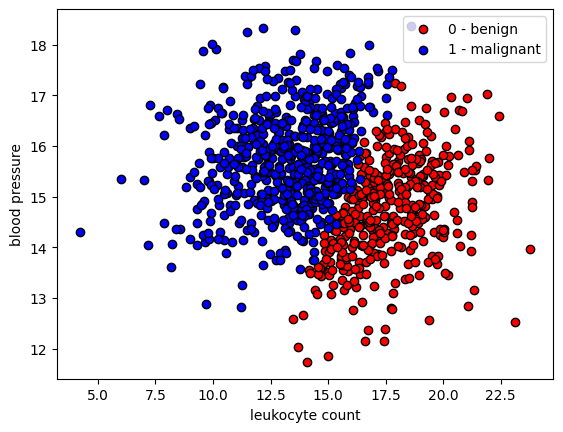

In [10]:
# Plot data
plot_tumors(df)

In [11]:
import pandas as pd
import torch

# 1. 从 DataFrame 里取出 2 个特征 → 转成 numpy 数组
X = df[['leukocyte_count', 'blood_pressure']].to_numpy(dtype='float32')

# 2. 取出标签 → 转成 numpy 数组
y = df['tumor'].to_numpy(dtype='int64') 

# 3. 把 numpy 数组 → 转成 PyTorch 张量
X = torch.from_numpy(X.copy())
y = torch.from_numpy(y.copy())

In [12]:
# 打乱数据顺序，避免数据按类别有序排列影响训练
shuffle_indicies = torch.LongTensor(random.sample(range(0, len(X)), len(X)))
X = X[shuffle_indicies]  # 根据打乱的索引重新排列特征
y = y[shuffle_indicies]  # 标签和特征保持对应，同步打乱

# 划分训练集和测试集
test_start_idx = int(len(X) * args.train_size)  # 计算训练集与测试集的分界点
X_train = X[:test_start_idx]                     # 前75%作为训练特征
y_train = y[:test_start_idx]                     # 前75%对应的训练标签
X_test = X[test_start_idx:]                      # 后25%作为测试特征
y_test = y[test_start_idx:]                      # 后25%对应的测试标签

# 输出训练集、测试集样本数量
print("We have %i train samples and %i test samples." % (len(X_train), len(X_test)))

We have 750 train samples and 250 test samples.


# 模型 Model

基于这个人造数据训练模型。

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [14]:
# 多层感知 Multilayer Perceptron 
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x_in, apply_softmax=False):
        a_1 = F.relu(self.fc1(x_in)) # activaton function added!
        y_pred = self.fc2(a_1)

        if apply_softmax:
            y_pred = F.softmax(y_pred, dim=1)

        return y_pred

In [15]:
# Initialize model
model = MLP(input_dim=len(df.columns)-1,  # 总列数里，包含了标签列（tumor），它不是输入特征，必须减掉
            hidden_dim=args.num_hidden_units, 
            output_dim=len(set(df.tumor)))

In [16]:
# Optimization
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=args.learning_rate) 

In [17]:
# Accuracy
def get_accuracy(y_pred, y_target):
    n_correct = torch.eq(y_pred, y_target).sum().item()
    accuracy = n_correct / len(y_pred) * 100
    return accuracy

In [18]:
# Training
# 设备配置 (自动选择 GPU 或 CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 将模型和数据移到设备上
model = model.to(device)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

model.train()  # 显式设置为训练模式 (启用 Dropout/BatchNorm)

for t in range(args.num_epochs):
    # Forward pass
    y_pred = model(X_train)
    
    # Accuracy
    _, predictions = y_pred.max(dim=1)
    accuracy = get_accuracy(y_pred=predictions.long(), y_target=y_train)

    # Loss
    loss = loss_fn(y_pred, y_train)
    
    # Verbose
    if t%20==0: 
        print ("epoch: {0:02d} | loss: {1:.4f} | accuracy: {2:.1f}%".format(
            t, loss, accuracy))

    # Zero all gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

Using device: cuda
epoch: 00 | loss: 2.4149 | accuracy: 38.4%
epoch: 20 | loss: 0.5191 | accuracy: 91.9%
epoch: 40 | loss: 0.3327 | accuracy: 89.6%
epoch: 60 | loss: 0.2231 | accuracy: 98.7%
epoch: 80 | loss: 0.1611 | accuracy: 99.1%


In [19]:
# Predictions
_, pred_train = model(X_train, apply_softmax=True).max(dim=1)
_, pred_test = model(X_test, apply_softmax=True).max(dim=1)

In [20]:
# Train and test accuracies
train_acc = get_accuracy(y_pred=pred_train, y_target=y_train)
test_acc = get_accuracy(y_pred=pred_test, y_target=y_test)
print ("train acc: {0:.1f}%, test acc: {1:.1f}%".format(train_acc, test_acc))

train acc: 99.1%, test acc: 97.6%


In [21]:
# Visualization
def plot_multiclass_decision_boundary(model, X, y):
    # 🔥 修复 1：如果 X 是张量，先转到 CPU
    if isinstance(X, torch.Tensor):
        X = X.cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.cpu().numpy()

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))
    cmap = plt.cm.Spectral
    
    X_test = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()

    # 🔥 修复 2：把输入数据送到模型所在的设备（GPU/CPU 自动适配）
    device = next(model.parameters()).device
    X_test = X_test.to(device)

    # 原来的代码不动
    y_pred = model(X_test, apply_softmax=True)
    _, y_pred = y_pred.max(dim=1)
    
    # 🔥 修复 3：预测结果转回 CPU
    y_pred = y_pred.cpu().numpy()

    y_pred = y_pred.reshape(xx.shape)
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

我们将绘制一个白色点，这个点已知是一个恶性肿瘤。我们训练后的模型可以精确的预测它确实是一个恶性肿瘤。

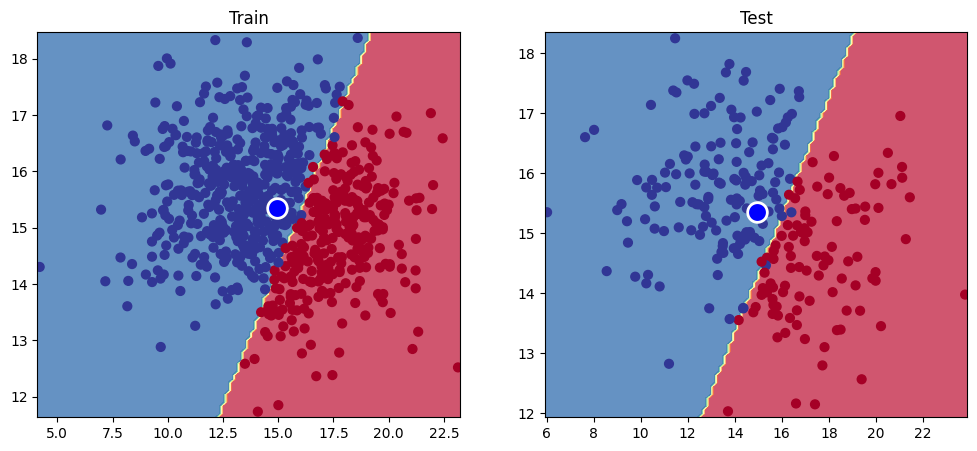

In [22]:
# Visualize the decision boundary
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_multiclass_decision_boundary(model=model, X=X_train, y=y_train)
plt.scatter(np.mean(df.leukocyte_count), np.mean(df.blood_pressure), s=200, 
            c='b', edgecolor='w', linewidth=2)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_multiclass_decision_boundary(model=model, X=X_test, y=y_test)
plt.scatter(np.mean(df.leukocyte_count), np.mean(df.blood_pressure), s=200, 
            c='b', edgecolor='w', linewidth=2)
plt.show()

完美！我们得到了测试和训练上非常好的表现。我们将用这个数据展示数据质量和数量的重要性。

# 数据质量和数量 Data Quality and Quantity

我们去除决策边界附件的一些训练数据，观察模型的鲁棒性如何。

In [23]:
# Upload data from GitHub to notebook's local drive
url = "https://raw.githubusercontent.com/LisonEvf/practicalAI-cn/master/data/tumors_reduced.csv"
response = urllib.request.urlopen(url)
html = response.read()
with open(args.reduced_data_file, 'wb') as fp:
    fp.write(html)

In [24]:
# Raw reduced data
df_reduced = pd.read_csv(args.reduced_data_file, header=0)
df_reduced.head()

,leukocyte_count,blood_pressure,tumor
0,13.472969,15.250393,1
1,10.805510,14.109676,1
2,13.834053,15.793920,1
3,9.572811,17.873286,1
4,7.633667,16.598559,1


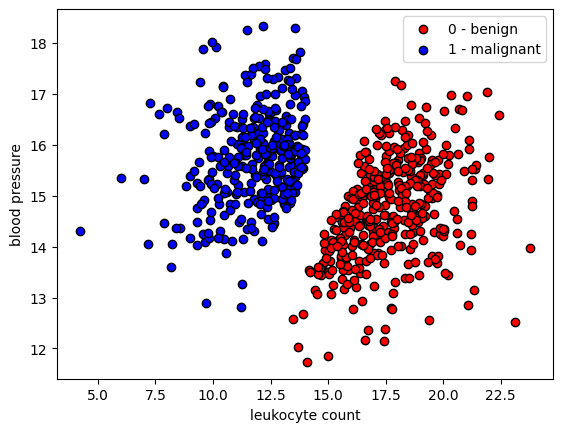

In [25]:
# Plot data
plot_tumors(df_reduced)

In [26]:
import pandas as pd
import torch

X = df[['leukocyte_count', 'blood_pressure']].to_numpy(dtype='float32')
y = df['tumor'].to_numpy(dtype='int64') # 分类任务通常需要是 long 类型

X = torch.from_numpy(X.copy())
y = torch.from_numpy(y.copy())

In [27]:
# Shuffle data
shuffle_indicies = torch.LongTensor(random.sample(range(0, len(X)), len(X)))
X = X[shuffle_indicies]
y = y[shuffle_indicies]

# Split datasets
test_start_idx = int(len(X) * args.train_size)
X_train = X[:test_start_idx] 
y_train = y[:test_start_idx] 
X_test = X[test_start_idx:] 
y_test = y[test_start_idx:]
print("We have %i train samples and %i test samples." % (len(X_train), len(X_test)))

We have 750 train samples and 250 test samples.


In [28]:
# Initialize model
model = MLP(input_dim=len(df_reduced.columns)-1, 
            hidden_dim=args.num_hidden_units, 
            output_dim=len(set(df_reduced.tumor)))

In [29]:
# Optimization
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=args.learning_rate) 

In [30]:
# Training
for t in range(args.num_epochs):
    # Forward pass
    y_pred = model(X_train)
    
    # Accuracy
    _, predictions = y_pred.max(dim=1)
    accuracy = get_accuracy(y_pred=predictions.long(), y_target=y_train)

    # Loss
    loss = loss_fn(y_pred, y_train)
    
    # Verbose
    if t%20==0: 
        print ("epoch: {0} | loss: {1:.4f} | accuracy: {2:.1f}%".format(t, loss, accuracy))

    # Zero all gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weights
    optimizer.step()

epoch: 0 | loss: 1.1217 | accuracy: 39.9%
epoch: 20 | loss: 0.4454 | accuracy: 80.0%
epoch: 40 | loss: 0.2862 | accuracy: 94.4%
epoch: 60 | loss: 0.1951 | accuracy: 98.0%
epoch: 80 | loss: 0.1292 | accuracy: 98.7%


In [31]:
# Predictions
_, pred_train = model(X_train, apply_softmax=True).max(dim=1)
_, pred_test = model(X_test, apply_softmax=True).max(dim=1)

In [32]:
# Train and test accuracies
train_acc = get_accuracy(y_pred=pred_train, y_target=y_train)
test_acc = get_accuracy(y_pred=pred_test, y_target=y_test)
print ("train acc: {0:.1f}%, test acc: {1:.1f}%".format(train_acc, test_acc))

train acc: 98.9%, test acc: 98.8%


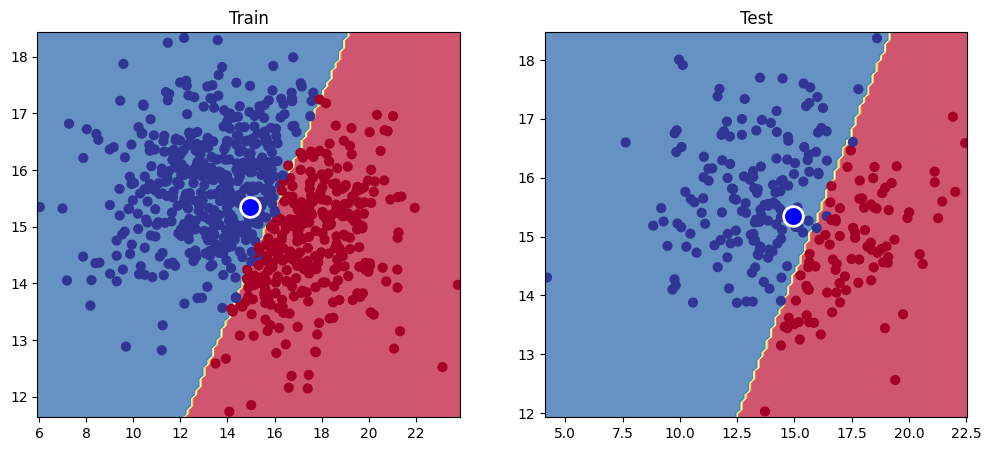

In [33]:
# Visualize the decision boundary
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_multiclass_decision_boundary(model=model, X=X_train, y=y_train)
plt.scatter(np.mean(df.leukocyte_count), np.mean(df.blood_pressure), s=200, 
            c='b', edgecolor='w', linewidth=2)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_multiclass_decision_boundary(model=model, X=X_test, y=y_test)
plt.scatter(np.mean(df.leukocyte_count), np.mean(df.blood_pressure), s=200, 
            c='b', edgecolor='w', linewidth=2)
plt.show()

这是一个非常惊人而又现实的情景。基于我们删减的人造数据，我们得到了一个在测试数据上表现非常好的模型。但是，当我们我使用之前相同的白色点（已知是良性肿瘤）进行测试时，预测显示是一个恶性肿瘤。我们完全误判了肿瘤。

**模型不是水晶球** 
在开始机器学习之前，很重要的一点是：我们需要观察我们的数据，并且扪心自问他们是否真实表示了我们将解决的问题。如果开始时的数据质量很差，即使训练很好，并且在测试数据上也很一致，这个模型依然是不可信的。

# 模型 Models

一旦你自信地认为你的数据质量和数量都非常好，你可以开始思考模型了。你选择模型的类型取决于很多因素，包括：任务、数据类型、需求复杂度等。

<img src="https://raw.githubusercontent.com/LisonEvf/practicalAI-cn/master/images/models1.png" width=550>

当你一旦搞清楚你的任务需要的模型类型时，从一个简单的模型开始，逐渐增加复杂度。你肯定不想直接从神经网络开始，因为很可能不是你数据和任务的正确模型。平衡模型的复杂度是你数据科学生涯的主要关键任务。**简单模型 → 复杂模型**